# MLP Classifier for MNIST

In [1]:
import numpy as np
import struct
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import seaborn as sns

%matplotlib inline

## Load data

In [2]:
def read_idx_images(filename):
    with open(filename, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows, cols)
    return images

def read_idx_labels(filename):
    with open(filename, 'rb') as f:
        magic, num_labels = struct.unpack('>II', f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

train_images = read_idx_images('../data/train-images.idx3-ubyte')
train_labels = read_idx_labels('../data/train-labels.idx1-ubyte')
test_images = read_idx_images('../data/t10k-images.idx3-ubyte')
test_labels = read_idx_labels('../data/t10k-labels.idx1-ubyte')

print(f"Train: {train_images.shape}, Test: {test_images.shape}")

Train: (60000, 28, 28), Test: (10000, 28, 28)


## Preprocess

In [3]:
X_train = train_images.reshape(len(train_images), -1).astype('float32') / 255.0
X_test = test_images.reshape(len(test_images), -1).astype('float32') / 255.0
y_train = train_labels
y_test = test_labels

print(f"Flattened: {X_train.shape}")

Flattened: (60000, 784)


## Find best architecture

In [4]:
X_subset = X_train[:10000]
y_subset = y_train[:10000]

configs = [(64,), (128,), (128, 64), (256, 128, 64)]
scores = []

for config in configs:
    mlp = MLPClassifier(hidden_layer_sizes=config, max_iter=50, random_state=42)
    cv = cross_val_score(mlp, X_subset, y_subset, cv=3)
    scores.append(cv.mean())
    print(f"{config}: {cv.mean():.4f}")

best_config = configs[np.argmax(scores)]
print(f"Best: {best_config}")

/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


(64,): 0.9359


/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


(128,): 0.9425


/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/brunopfohl/Downloads/digits/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


(128, 64): 0.9454
(256, 128, 64): 0.9477
Best: (256, 128, 64)


## Train

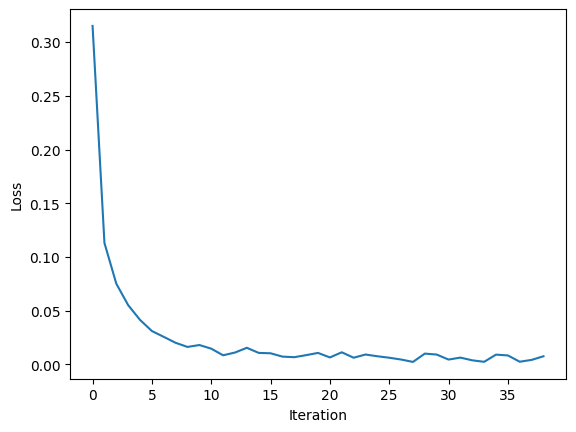

In [5]:
mlp = MLPClassifier(hidden_layer_sizes=best_config, max_iter=200, random_state=42)
mlp.fit(X_train, y_train)

plt.plot(mlp.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

## Evaluate

In [6]:
y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9821


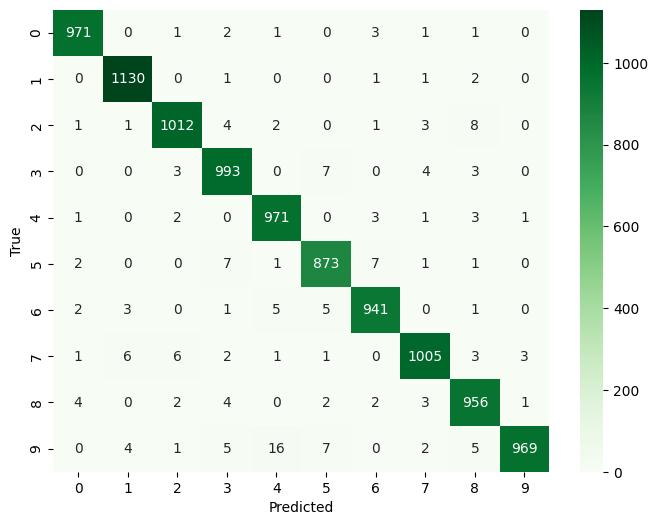

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

## Errors

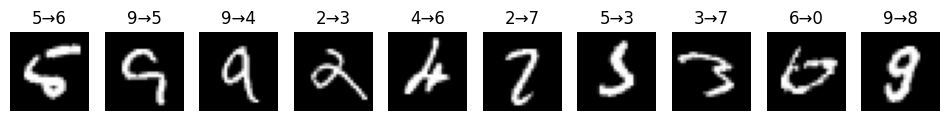

In [8]:
wrong = np.where(y_pred != y_test)[0][:10]

fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, idx in enumerate(wrong):
    axes[i].imshow(test_images[idx], cmap='gray')
    axes[i].set_title(f'{y_test[idx]}→{y_pred[idx]}')
    axes[i].axis('off')
plt.show()